# 오프라인 거래 이동속도(raw speed) 구간별 사기율 분석

`high_speed` 변수의 임계값(100km/h)이 적절한지 판단하기 위해, 직전 오프라인
거래 대비 이동속도를 이진화하지 않고 구간별로 나눠서 실제 사기율이 어디서
뛰는지 직접 확인하는 진단용 노트북이다.

이 노트북은 `build_leakfree_features.ipynb`와 별개로 독립 실행 가능하도록
필요한 함수(경로 탐색, 데이터 로드, haversine 등)를 자체적으로 포함한다.

## 사용법

1. 아래 경로 설정 셀에서 raw csv 경로를 확인한다 (이미 채워져 있음).
2. 위에서부터 순서대로 셀을 실행한다.
3. 출력: 콘솔의 구간별 사기율 표 + `speed_bin_fraud_rate.csv`
4. `lift_vs_overall`이 1.0을 넘는 구간부터가 "전체 평균보다 위험한 구간"이다.
   이 값이 몇 km/h부터 뚜렷하게 올라가는지를 보고 100 vs 140 등 임계값을
   다시 판단하면 된다.

## 0. 경로 설정

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

CANDIDATE_TRAIN_PATHS = [
    Path(r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain.csv"),
    Path(r"C:\Users\splen\OneDrive\Desktop\BDAI\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain.csv"),
    Path("data/raw/fraudTrain.csv"),
    Path("fraudTrain.csv"),
]

CANDIDATE_TEST_PATHS = [
    Path(r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTest.csv"),
    Path(r"C:\Users\splen\OneDrive\Desktop\BDAI\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTest.csv"),
    Path("data/raw/fraudTest.csv"),
    Path("fraudTest.csv"),
]

ONLINE_CATEGORIES = {"shopping_net", "misc_net", "grocery_net"}

SPEED_BINS = [0, 50, 100, 140, 200, 300, 500, 1000, np.inf]
SPEED_LABELS = ["0-50", "50-100", "100-140", "140-200", "200-300", "300-500", "500-1000", "1000+"]


def find_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "원본 csv를 찾지 못했습니다. CANDIDATE_TRAIN_PATHS / CANDIDATE_TEST_PATHS 를 "
        "실제 경로로 고쳐주세요.\n시도한 경로:\n" + "\n".join(str(p) for p in candidates)
    )


## 1. 유틸 함수 (build_leakfree_features.ipynb와 동일 로직)

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def load_raw(path: Path, source: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
    required = {"trans_num", "trans_date_trans_time", "cc_num", "category", "amt",
                "merch_lat", "merch_long", "is_fraud"}
    missing = required.difference(df.columns)
    assert not missing, f"{path} 에 필수 컬럼이 없습니다: {missing}"
    assert df["trans_num"].is_unique, f"{path}: trans_num 중복 존재"
    df["_source"] = source
    return df


def add_current_row_features(df: pd.DataFrame) -> pd.DataFrame:
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="raise")
    df["is_online"] = df["category"].isin(ONLINE_CATEGORIES)
    return df


def compute_raw_speed(df: pd.DataFrame) -> pd.DataFrame:
    """오프라인 거래에 대해 이진화 전 원본 이동속도(km/h)를 계산한다."""
    df = df.sort_values(["cc_num", "trans_date_trans_time", "trans_num"], kind="mergesort").reset_index(drop=True)
    offline_mask = ~df["is_online"]
    off = df.loc[offline_mask].copy()
    off = off.sort_values(["cc_num", "trans_date_trans_time", "trans_num"], kind="mergesort")

    off["prev_merch_lat"] = off.groupby("cc_num")["merch_lat"].shift(1)
    off["prev_merch_long"] = off.groupby("cc_num")["merch_long"].shift(1)
    off["prev_trans_time"] = off.groupby("cc_num")["trans_date_trans_time"].shift(1)

    dist_km = haversine(off["prev_merch_lat"], off["prev_merch_long"], off["merch_lat"], off["merch_long"])
    hours = (off["trans_date_trans_time"] - off["prev_trans_time"]).dt.total_seconds() / 3600

    with np.errstate(divide="ignore", invalid="ignore"):
        raw_speed = np.where(hours > 0, dist_km / hours, np.nan)
    off = off.copy()
    off["raw_speed_kmh"] = raw_speed

    keep = off[["trans_num", "raw_speed_kmh"]]
    df = df.merge(keep, on="trans_num", how="left")
    return df


## 2. 데이터 로드 및 속도 계산

In [3]:
train_path = find_path(CANDIDATE_TRAIN_PATHS)
test_path = find_path(CANDIDATE_TEST_PATHS)

train_raw = load_raw(train_path, "train")
test_raw = load_raw(test_path, "test")
combined = pd.concat([train_raw, test_raw], ignore_index=True)
combined = add_current_row_features(combined)
combined = compute_raw_speed(combined)

has_prior = combined["raw_speed_kmh"].notna()
print(f"직전 오프라인 거래가 있어 속도 계산이 가능한 거래 수: {has_prior.sum():,} / 전체 {len(combined):,}")

overall_fraud_rate = combined["is_fraud"].mean()
print(f"전체 사기율: {overall_fraud_rate*100:.4f}%")


직전 오프라인 거래가 있어 속도 계산이 가능한 거래 수: 1,556,508 / 전체 1,852,394
전체 사기율: 0.5210%


## 3. 속도 구간별 사기율 / lift

In [4]:
scoped = combined.loc[has_prior].copy()
scoped["speed_bin"] = pd.cut(scoped["raw_speed_kmh"], bins=SPEED_BINS, labels=SPEED_LABELS, right=False)

summary = (
    scoped.groupby("speed_bin", observed=True)
    .agg(
        transaction_count=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
    )
    .reset_index()
)
summary["fraud_rate_pct"] = (summary["fraud_rate"] * 100).round(4)
summary["lift_vs_overall"] = (summary["fraud_rate"] / overall_fraud_rate).round(2)

summary


,speed_bin,transaction_count,fraud_count,fraud_rate,fraud_rate_pct,lift_vs_overall
0,0-50,1150456,3523,0.003062,0.3062,0.59
1,50-100,171277,718,0.004192,0.4192,0.80
2,100-140,59295,350,0.005903,0.5903,1.13
3,140-200,48057,323,0.006721,0.6721,1.29
4,200-300,39885,310,0.007772,0.7772,1.49
5,300-500,33842,253,0.007476,0.7476,1.43
6,500-1000,26172,249,0.009514,0.9514,1.83
7,1000+,27524,258,0.009374,0.9374,1.80


C:\Users\splen\AppData\Local\Temp\ipykernel_34076\2330553235.py:10: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\splen\AppData\Local\Temp\ipykernel_34076\2330553235.py:10: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\splen\AppData\Local\Temp\ipykernel_34076\2330553235.py:10: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\splen\AppData\Local\Temp\ipykernel_34076\2330553235.py:10: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\splen\AppData\Local\Temp\ipykernel_34076\2330553235.py:10: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\splen\AppData\Local\Temp\ipykernel_34076\2330553235.py:10: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from f

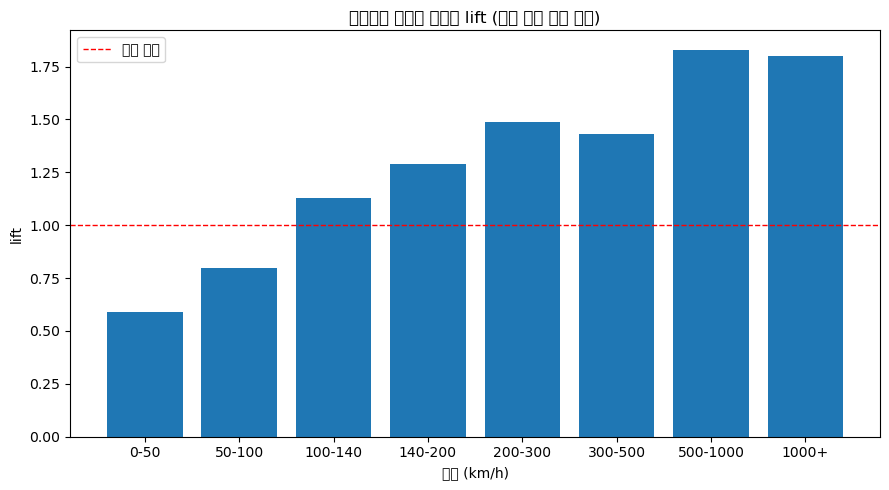

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.bar(summary["speed_bin"].astype(str), summary["lift_vs_overall"])
plt.axhline(1.0, color="red", linestyle="--", linewidth=1, label="전체 평균")
plt.title("이동속도 구간별 사기율 lift (전체 평균 대비 배수)")
plt.xlabel("구간 (km/h)")
plt.ylabel("lift")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
summary.to_csv("speed_bin_fraud_rate.csv", index=False, encoding="utf-8-sig")
print("저장 완료: speed_bin_fraud_rate.csv")


저장 완료: speed_bin_fraud_rate.csv
